In [36]:
import pandas as pd
import numpy as np

data_cell = pd.read_csv(f"../ccRCC/NarrowUtility/CellDecovo/ResultsDA_cibersortx/Origin.csv")

data_cell['Rank_score'] = np.sign(data_cell['Diff_Mean'])*(-np.log10(data_cell['P_values']))
data_cell = data_cell.sort_values(by='Rank_score', ascending = False).reset_index(drop=True)

top_5_up = data_cell.iloc[0:5,0].values.tolist()
top_5_down = data_cell.iloc[-6:-1,0].values.tolist()

#Melanoma 
data_cell_melanoma = pd.read_csv(f"../Melanoma/NarrowUtility/CellDecovo/ResultsDA/Origin_overall.csv")

data_cell_melanoma['Rank_score'] = np.sign(data_cell_melanoma['Diff_Mean'])*(-np.log10(data_cell_melanoma['P_values']))
data_cell_melanoma = data_cell_melanoma.sort_values(by='Rank_score', ascending = False).reset_index(drop=True)

top_5_up_melanoma = data_cell_melanoma.iloc[0:5,0].values.tolist()
top_5_down_melanoma = data_cell_melanoma.iloc[-6:-1,0].values.tolist()

#NSCLC
data_cell_nsclc = pd.read_csv(f"../NSCLC/NarrowUtility/CellDeco/ResultsDA_cibersortx/Origin.csv")

data_cell_nsclc['Rank_score'] = np.sign(data_cell_nsclc['Diff_Mean'])*(-np.log10(data_cell_nsclc['P_values']))
data_cell_nsclc = data_cell_nsclc.sort_values(by='Rank_score', ascending = False).reset_index(drop=True)

top_5_up_nsclc = data_cell_nsclc.iloc[0:5,0].values.tolist()
top_5_down_nsclc = data_cell_nsclc.iloc[-6:-1,0].values.tolist()

top_up_both = list(set(top_5_up)&set(top_5_up_melanoma)&set(top_5_up_nsclc))
top_down_both = list(set(top_5_down)&set(top_5_down_melanoma)&set(top_5_down_nsclc))

In [50]:
data_cell_melanoma

,Cell Type,P_values,Q_values,Diff_Mean,Rank_score
0,B cells naive,0.160415,0.960707,0.184595,0.794754
1,NK cells activated,0.298565,0.960707,0.198070,0.524961
2,Dendritic cells resting,0.446401,0.960707,0.351903,0.350274
3,Dendritic cells activated,0.448381,0.960707,0.019494,0.348353
4,T cells CD8,0.628853,0.960707,0.335055,0.201451
5,Macrophages M0,0.631206,0.960707,2.540999,0.199829
6,Macrophages M1,0.659717,0.960707,0.255343,0.180642
7,NK cells resting,0.773333,0.960707,0.185669,0.111634
8,B cells memory,0.780946,0.960707,0.325034,0.107379
9,T cells follicular helper,0.899889,0.997359,0.122418,0.045811


In [97]:
import pandas as pd
import numpy as np 

# terms = ['T cells CD8', 'T cells follicular helper', 'Dendritic cells activated', 'Eosinophils',
#          'Macrophages M2', 'T cells CD4 memory resting', 'NK cells activated']
# terms = data_cell['Cell Type'].values.tolist()
terms = data_cell[data_cell['Q_values']<= 0.25]['Cell Type'].values.tolist()

#ccRCC 
ccRCC_nes = {}
names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop']
# seeds = [2,0,42,42,2]
datasets = ['avatarsk5_42', 'avatarsk10_42', 'ctgan_42', 'gaussiancopula_42', 'synthpop_42']
# seed = 3
# datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}', f'ctgan_{seed}', f'gaussiancopula_{seed}', f'synthpop_{seed}']
gsea_res_or = pd.read_csv(f"../ccRCC/NarrowUtility/CellDecovo/ResultsDA_cibersortx/Origin.csv")
gsea_nes_or= gsea_res_or[gsea_res_or['Cell Type'].isin(terms)][['Cell Type','Diff_Mean']].values.tolist()
ccRCC_nes['Original Direction'] = gsea_nes_or
seeds = [42,42,42,42,42]
for i, dataset in enumerate(datasets): 
    gsea_res = pd.read_csv(f'../ccRCC/NarrowUtility/CellDecovo/ResultsDA_cibersortx/Seed_{seeds[i]}/{dataset}.csv')
    # gsea_res = pd.read_csv(f'../ccRCC/NarrowUtility/GSEA/NivoBenefit/Seed_{seed}/GSEA_{dataset}.csv')
    gsea_nes_syn= gsea_res[gsea_res['Cell Type'].isin(terms)][['Cell Type','Diff_Mean']].values.tolist()
    ccRCC_nes[names[i]] = gsea_nes_syn

#Melanoma 
Melanoma_nes = {}
names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
datasets = ['avatarsk5_42', 'avatarsk10_42', 'ctgan_42', 'gaussiancopula_42', 'synthpop_42','tvae_42']
gsea_res_or = pd.read_csv(f"../Melanoma/NarrowUtility/CellDecovo/ResultsDA/Origin_overall.csv")
gsea_nes_or= gsea_res_or[gsea_res_or['Cell Type'].isin(terms)][['Cell Type','Diff_Mean']].values.tolist()
Melanoma_nes['Original Direction'] = gsea_nes_or
seeds = [42,42,42,42,42, 42]
for i, dataset in enumerate(datasets): 
    gsea_res = pd.read_csv(f'../Melanoma/NarrowUtility/CellDecovo/ResultsDA/Seed_{seeds[i]}/{dataset}_overall.csv')
    gsea_nes_syn= gsea_res[gsea_res['Cell Type'].isin(terms)][['Cell Type','Diff_Mean']].values.tolist()
    Melanoma_nes[names[i]] = gsea_nes_syn

#NSCLC 
NSCLC_nes = {}
names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
datasets = ['avatarsk5_42', 'avatarsk10_42', 'ctgan_42', 'gaussiancopula_42', 'synthpop_42','tvae_42']
gsea_res_or = pd.read_csv(f"../NSCLC/NarrowUtility/CellDeco/ResultsDA_cibersortx/Origin.csv")
gsea_nes_or= gsea_res_or[gsea_res_or['Cell Type'].isin(terms)][['Cell Type','Diff_Mean']].values.tolist()
NSCLC_nes['Original Direction'] = gsea_nes_or
seeds = [42,42,42,42,42, 42]
for i, dataset in enumerate(datasets): 
    gsea_res = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/ResultsDA_cibersortx/Seed_{seeds[i]}/{dataset}.csv')
    gsea_nes_syn= gsea_res[gsea_res['Cell Type'].isin(terms)][['Cell Type','Diff_Mean']].values.tolist()
    NSCLC_nes[names[i]] = gsea_nes_syn

#Overall
NES_dict = {'ccRCC': ccRCC_nes,
           'Melanoma': Melanoma_nes, 'NSCLC':NSCLC_nes}

In [46]:
from __future__ import annotations

from typing import Dict, List, Optional, Sequence, Tuple, Set

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm


NATURE_FONT = {
    "family": "sans-serif",
    "sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
}

CANCER_COLORS = {
    "ccRCC": "#4C72B0",
    "Melanoma": "#DD8452",
    "NSCLC": "#55A868",
}

STABILITY_PLOT_COLORS = {
    "heatmap_bg": "#f7f7f7",
    "missing_edge": "#BDBDBD",
    "missing_face": "#FFFFFF",
}

# Agreement palette (Okabe–Ito-ish, colorblind friendly)
AGREE_DISAGREE_COLORS = {
    "agree": "#0072B2",      # blue
    "disagree": "#D55E00",   # vermillion/orange
    "neutral": "#E6E6E6",    # light gray
}

# Origin direction palette (distinct from agreement)
ORIGIN_DIR_COLORS = {
    "up": "#7B3294",       # purple
    "down": "#008837",     # green/teal
    "neutral": "#E6E6E6",  # gray
}


def _set_nature_rcparams(fontsize: int = 11) -> None:
    """
    Apply Nature-like matplotlib rcParams (Helvetica/Arial and clean axes).

    Args:
        fontsize (int): Base font size for the figure.

    Raises:
        ValueError: If fontsize is not positive.
    """
    if fontsize <= 0:
        raise ValueError("fontsize must be a positive integer.")

    plt.rcParams.update(
        {
            "font.size": fontsize,
            "font.family": NATURE_FONT["family"],
            "font.sans-serif": NATURE_FONT["sans-serif"],
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "axes.titlesize": fontsize + 1,
            "axes.labelsize": fontsize,
            "xtick.labelsize": fontsize - 1,
            "ytick.labelsize": fontsize - 1,
            "legend.fontsize": fontsize - 1,
        }
    )


def _shorten_hallmark_term(term: str) -> str:
    """
    Convert MSigDB Hallmark term into a shorter pathway label for y-axis.

    Args:
        term (str): Raw Hallmark term.

    Returns:
        str: Shortened label.

    Raises:
        ValueError: If term is empty.
    """
    if term is None or str(term).strip() == "":
        raise ValueError("term must be a non-empty string.")

    t = str(term).strip().upper()
    if t.startswith("HALLMARK_"):
        t = t.replace("HALLMARK_", "", 1)

    mapping = {
        "INTERFERON_ALPHA_RESPONSE": r"IFN$\alpha$ response",
        "INTERFERON_GAMMA_RESPONSE": r"IFN$\gamma$ response",
        "IL6_JAK_STAT3_SIGNALING": "IL6–JAK–STAT3",
        "INFLAMMATORY_RESPONSE": "Inflammatory",
        "TGF_BETA_SIGNALING": r"TGF-$\beta$",
        "DNA_REPAIR": "DNA repair",
        "ALLOGRAFT_REJECTION": "Allograft rejection",
        "COMPLEMENT": "Complement",
        "EPITHELIAL_MESENCHYMAL_TRANSITION": "EMT",
        "WNT_BETA_CATENIN_SIGNALING": r"WNT/$\beta$-catenin",
    }
    return mapping.get(t, t.replace("_", " ").title())


def build_origin_nes_sign_vector(
    cancer_nes: Dict[str, List[List[float]]],
    origin_key: str,
    terms_order: Sequence[str],
    sign_eps: float = 1e-8,
) -> pd.Series:
    """
    Build a vector indicating Origin NES direction per pathway.

    Args:
        cancer_nes (Dict[str, List[List[float]]]): Mapping method -> list of [Term, NES].
        origin_key (str): Key for Origin method.
        terms_order (Sequence[str]): Global term order.
        sign_eps (float): Threshold to treat NES close to 0 as neutral.

    Returns:
        pd.Series: Indexed by shortened pathway names, values in {-1, 0, 1, NaN}.

    Raises:
        ValueError: If origin_key is missing.
        ValueError: If terms_order is empty.
    """
    if origin_key not in cancer_nes:
        raise ValueError(f"origin_key '{origin_key}' not found in cancer_nes keys: {sorted(cancer_nes.keys())}")
    if len(list(terms_order)) == 0:
        raise ValueError("terms_order must be provided and non-empty.")

    df = pd.DataFrame(cancer_nes[origin_key], columns=["Term", "NES"])
    df["Term"] = df["Term"].astype(str)
    df["NES"] = pd.to_numeric(df["NES"], errors="coerce")
    df = df.dropna(subset=["Term", "NES"])
    s = df.set_index("Term")["NES"]

    out = []
    for t in list(terms_order):
        if t not in s.index:
            out.append(np.nan)
            continue
        x = float(s.loc[t])
        if not np.isfinite(x) or abs(x) <= sign_eps:
            out.append(0.0)
        else:
            out.append(1.0 if x > 0 else -1.0)

    idx = [_shorten_hallmark_term(t) for t in list(terms_order)]
    return pd.Series(out, index=idx, name=origin_key)


def build_nes_direction_agreement_matrix(
    cancer_nes: Dict[str, List[List[float]]],
    origin_key: str = "Original Direction",
    terms_order: Sequence[str] = (),
    methods_order: Optional[Sequence[str]] = None,
    sign_eps: float = 1e-8,
) -> pd.DataFrame:
    """
    Build a pathway x method matrix encoding direction agreement of NES vs Origin.

    Encoding:
        1  -> agreement (same sign)
        0  -> disagreement (opposite sign)
       -1  -> neutral (one is ~0)
        NaN -> missing term for that method (or missing in Origin)

    Args:
        cancer_nes (Dict[str, List[List[float]]]): Mapping method -> list of [Term, NES].
        origin_key (str): Key for the Origin method.
        terms_order (Sequence[str]): Global term order (shared across cancers).
        methods_order (Optional[Sequence[str]]): Optional ordering of methods (columns).
        sign_eps (float): Threshold to treat NES close to 0 as neutral.

    Returns:
        pd.DataFrame: Matrix indexed by shortened pathway names, columns by methods.

    Raises:
        ValueError: If origin_key is missing.
        ValueError: If terms_order is empty.
        ValueError: If sign_eps is negative.
    """
    if origin_key not in cancer_nes:
        raise ValueError(f"origin_key '{origin_key}' not found in cancer_nes keys: {sorted(cancer_nes.keys())}")
    if len(list(terms_order)) == 0:
        raise ValueError("terms_order must be provided and non-empty.")
    if sign_eps < 0:
        raise ValueError("sign_eps must be >= 0.")

    method_to_series: Dict[str, pd.Series] = {}
    for method, rows in cancer_nes.items():
        df = pd.DataFrame(rows, columns=["Term", "NES"])
        df["Term"] = df["Term"].astype(str)
        df["NES"] = pd.to_numeric(df["NES"], errors="coerce")
        df = df.dropna(subset=["Term", "NES"])
        method_to_series[str(method)] = df.set_index("Term")["NES"]

    origin_series = method_to_series[origin_key]
    methods = list(cancer_nes.keys()) if methods_order is None else list(methods_order)

    terms = list(terms_order)
    mat_raw = pd.DataFrame(index=terms, columns=methods, dtype=float)

    def _sign(x: float) -> int:
        if not np.isfinite(x):
            return 0
        if abs(x) <= sign_eps:
            return 0
        return 1 if x > 0 else -1

    for term in terms:
        if term not in origin_series.index:
            continue

        s0 = _sign(float(origin_series.loc[term]))

        for m in methods:
            s_m = method_to_series.get(m, pd.Series(dtype=float))
            if term not in s_m.index:
                continue
            sm = _sign(float(s_m.loc[term]))

            if s0 == 0 or sm == 0:
                mat_raw.loc[term, m] = -1.0
            else:
                mat_raw.loc[term, m] = 1.0 if (s0 == sm) else 0.0

    mat_raw.index = [_shorten_hallmark_term(t) for t in mat_raw.index]
    return mat_raw


def _paint_origin_column_with_direction(
    ax: plt.Axes,
    mat: pd.DataFrame,
    origin_dir: pd.Series,
    origin_col: str,
    missing_hatch: str,
    edge_lw: float,
) -> None:
    """
    Paint the Origin column cells using NES direction colors and draw a thicker border.

    Args:
        ax (plt.Axes): Heatmap axis.
        mat (pd.DataFrame): Full matrix already drawn as a heatmap.
        origin_dir (pd.Series): Origin NES sign vector indexed by mat.index (values -1/0/1/NaN).
        origin_col (str): Column name for Origin.
        missing_hatch (str): Hatch pattern for missing.
        edge_lw (float): Border line width for the Origin column.
    """
    if origin_col not in mat.columns:
        return

    j0 = list(mat.columns).index(origin_col)
    n_rows = mat.shape[0]

    # Overlay colored rectangles cell-by-cell for Origin column
    for i, pathway in enumerate(mat.index):
        v = origin_dir.get(pathway, np.nan)
        if pd.isna(v):
            # leave as-is (missing will be hatched by global hatch overlay)
            continue
        if v > 0:
            fc = ORIGIN_DIR_COLORS["up"]
        elif v < 0:
            fc = ORIGIN_DIR_COLORS["down"]
        else:
            fc = ORIGIN_DIR_COLORS["neutral"]

        rect = mpatches.Rectangle(
            (j0, i),
            1.0,
            1.0,
            facecolor=fc,
            edgecolor="lightgray",
            linewidth=0.5,
            zorder=15,
        )
        ax.add_patch(rect)

    # Thick border around the Origin column
    border = mpatches.Rectangle(
        (j0, 0),
        1.0,
        float(n_rows),
        fill=False,
        edgecolor="black",
        linewidth=edge_lw,
        zorder=20,
    )
    ax.add_patch(border)


def _overlay_hatched_missing_cells(ax: plt.Axes, mat: pd.DataFrame, hatch: str) -> None:
    """
    Overlay hatched rectangles on NaN cells in the matrix.

    Args:
        ax (plt.Axes): Axis containing the heatmap.
        mat (pd.DataFrame): Heatmap matrix (NaNs indicate missing cells).
        hatch (str): Matplotlib hatch pattern.
    """
    nan_mask = mat.isna().to_numpy()
    nrows, ncols = nan_mask.shape

    for i in range(nrows):
        for j in range(ncols):
            if not nan_mask[i, j]:
                continue
            rect = mpatches.Rectangle(
                (j, i),
                1.0,
                1.0,
                facecolor=STABILITY_PLOT_COLORS["missing_face"],
                edgecolor=STABILITY_PLOT_COLORS["missing_edge"],
                hatch=hatch,
                linewidth=0.6,
                fill=True,
                zorder=30,
            )
            ax.add_patch(rect)


def plot_nes_direction_agreement_heatmap_grid(
    nes_dict: Dict[str, Dict[str, List[List[float]]]],
    cancers_order: Sequence[str] = ("ccRCC", "Melanoma", "NSCLC"),
    origin_key: str = "Original Direction",
    terms_order: Sequence[str] = (),
    methods_order: Optional[Sequence[str]] = None,
    highlighted_pathways: Optional[Sequence[str]] = None,
    sign_eps: float = 1e-8,
    figsize: Tuple[int, int] = (18, 6),
    fontsize: int = 11,
    hatch_missing: bool = True,
    missing_hatch: str = "///",
    origin_edge_lw: float = 2.6,
    legend_bbox_to_anchor: Tuple[float, float] = (0.995, 1.0),
    legend_right_margin: float = 0.975,
    show: bool = True,
) -> Tuple[plt.Figure, np.ndarray, Dict[str, pd.DataFrame]]:
    """
    Plot a 1x3 grid of NES heatmaps where:
    - Origin column encodes Origin NES direction (Up/Down/Neutral)
    - Other columns encode agreement vs Origin (Agree/Disagree/Neutral)
    - Missing cells are hatched.

    Args:
        nes_dict (Dict[str, Dict[str, List[List[float]]]]): NES_dict[cancer][method] = [[Term, NES], ...].
        cancers_order (Sequence[str]): Order of cancers in the grid.
        origin_key (str): Key for Origin method in each cancer.
        terms_order (Sequence[str]): Global term order (shared across cancers). Must be non-empty.
        methods_order (Optional[Sequence[str]]): Optional ordering of methods (columns). Must include origin_key.
        highlighted_pathways (Optional[Sequence[str]]): Short pathway labels to render in bold on y-axis.
        sign_eps (float): Threshold to treat NES close to 0 as neutral.
        figsize (Tuple[int, int]): Figure size.
        fontsize (int): Base font size.
        hatch_missing (bool): If True, hatch missing (NaN) cells.
        missing_hatch (str): Hatch pattern used for missing cells.
        origin_edge_lw (float): Line width for border around Origin column.
        legend_bbox_to_anchor (Tuple[float, float]): Legend anchor (close to heatmaps).
        legend_right_margin (float): Right margin for tight_layout (higher -> less whitespace).
        show (bool): If True, calls plt.show().

    Returns:
        Tuple[plt.Figure, np.ndarray, Dict[str, pd.DataFrame]]: (fig, axes, matrices_by_cancer).

    Raises:
        ValueError: If cancers_order includes a cancer not found in nes_dict.
        ValueError: If terms_order is empty.
        ValueError: If methods_order is provided but does not include origin_key.
    """
    cancers_order = list(cancers_order)
    for c in cancers_order:
        if c not in nes_dict:
            raise ValueError(f"Cancer '{c}' missing from nes_dict keys: {sorted(nes_dict.keys())}")

    if len(list(terms_order)) == 0:
        raise ValueError("terms_order must be provided and non-empty.")

    if methods_order is not None and origin_key not in list(methods_order):
        raise ValueError("methods_order must include origin_key.")

    highlighted_set: Set[str] = set([str(x) for x in highlighted_pathways]) if highlighted_pathways else set()

    _set_nature_rcparams(fontsize=fontsize)
    sns.set(style="white", rc={"axes.facecolor": STABILITY_PLOT_COLORS["heatmap_bg"]})

    # Agreement colormap: -1 neutral, 0 disagree, 1 agree
    agree_cmap = ListedColormap(
        [AGREE_DISAGREE_COLORS["neutral"], AGREE_DISAGREE_COLORS["disagree"], AGREE_DISAGREE_COLORS["agree"]]
    )
    agree_norm = BoundaryNorm(boundaries=[-1.5, -0.5, 0.5, 1.5], ncolors=agree_cmap.N)

    fig, axes = plt.subplots(1, len(cancers_order), figsize=figsize)
    if len(cancers_order) == 1:
        axes = np.array([axes])

    matrices_by_cancer: Dict[str, pd.DataFrame] = {}

    for ax, cancer in zip(axes, cancers_order):
        cols = list(nes_dict[cancer].keys()) if methods_order is None else list(methods_order)

        # Agreement matrix (we will overwrite Origin column visually)
        agree_mat = build_nes_direction_agreement_matrix(
            cancer_nes=nes_dict[cancer],
            origin_key=origin_key,
            terms_order=terms_order,
            methods_order=cols,
            sign_eps=sign_eps,
        )
        agree_mat = agree_mat.reindex(columns=cols)

        # Origin direction vector aligned to y index
        origin_dir = build_origin_nes_sign_vector(
            cancer_nes=nes_dict[cancer],
            origin_key=origin_key,
            terms_order=terms_order,
            sign_eps=sign_eps,
        ).reindex(agree_mat.index)

        matrices_by_cancer[cancer] = agree_mat

        # Draw base heatmap ONCE (so we keep all columns)
        mask = agree_mat.isna()
        sns.heatmap(
            agree_mat,
            ax=ax,
            cmap=agree_cmap,
            norm=agree_norm,
            mask=mask if hatch_missing else None,
            linewidths=0.5,
            linecolor="lightgray",
            cbar=False,
            square=False,
        )

        # Now repaint Origin column with direction colors + thick border
        _paint_origin_column_with_direction(
            ax=ax,
            mat=agree_mat,
            origin_dir=origin_dir,
            origin_col=origin_key,
            missing_hatch=missing_hatch,
            edge_lw=origin_edge_lw,
        )

        # Hatch missing (on top)
        if hatch_missing:
            _overlay_hatched_missing_cells(ax=ax, mat=agree_mat, hatch=missing_hatch)

        ax.set_title(cancer, fontsize=fontsize + 1, fontweight="bold", pad=10)
        cancer_color = CANCER_COLORS.get(cancer, "#333333")
        ax.plot([0.02, 0.98], [1.02, 1.02], transform=ax.transAxes, color=cancer_color, lw=4, clip_on=False)

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

        for t in ax.get_xticklabels():
            t.set_horizontalalignment("right")
            t.set_rotation_mode("anchor")

        for tick in ax.get_yticklabels():
            if tick.get_text() in highlighted_set:
                tick.set_fontweight("bold")

    # Legend close to heatmaps
    legend_handles = [
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["up"], edgecolor="none", label=f"{origin_key}: NES > 0"),
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["down"], edgecolor="none", label=f"{origin_key}: NES < 0"),
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["neutral"], edgecolor="none", label=f"{origin_key}: NES≈0"),
        mpatches.Patch(facecolor=AGREE_DISAGREE_COLORS["agree"], edgecolor="none", label="Agreement: Agree"),
        mpatches.Patch(facecolor=AGREE_DISAGREE_COLORS["disagree"], edgecolor="none", label="Agreement: Disagree"),
        mpatches.Patch(facecolor=AGREE_DISAGREE_COLORS["neutral"], edgecolor="none", label="Agreement: Neutral"),
        mpatches.Patch(
            facecolor=STABILITY_PLOT_COLORS["missing_face"],
            edgecolor=STABILITY_PLOT_COLORS["missing_edge"],
            hatch=missing_hatch,
            label="Missing",
        ),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=legend_bbox_to_anchor,
        frameon=False,
        title="Legend",
        fontsize=fontsize - 1,
        title_fontsize=fontsize,
        borderaxespad=0.0,
        handletextpad=0.6,
    )

    # Keep legend close: reserve only a small right margin
    plt.tight_layout(rect=[0, 0, legend_right_margin, 1])

    if show:
        plt.show()

    return fig, axes, matrices_by_cancer

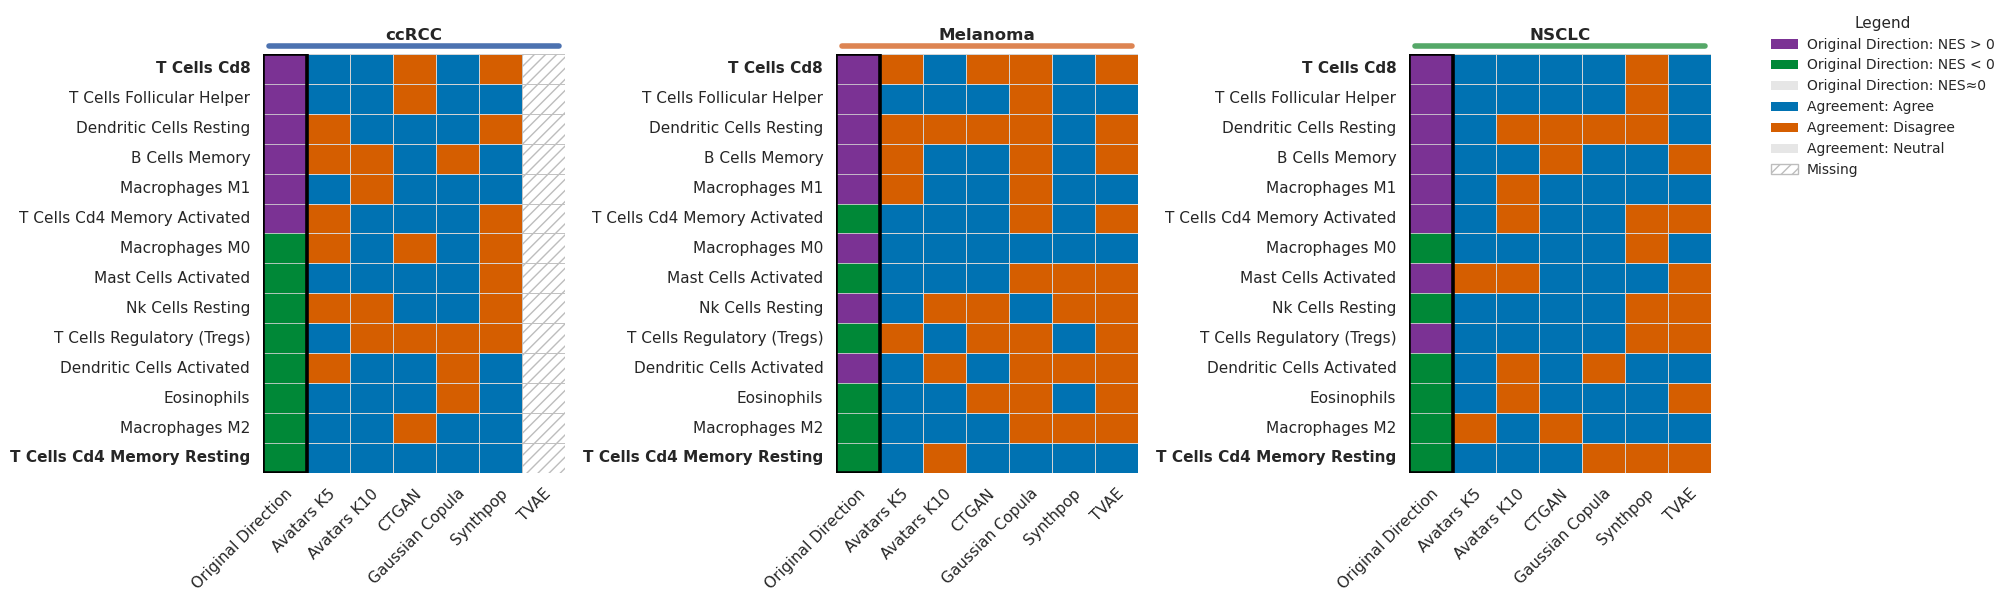

In [98]:
# from nes_direction_agreement import plot_nes_direction_agreement_heatmap_grid

methods_order = ["Original Direction", "Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
highlighted_pathways = ['T Cells Cd8', 'T Cells Cd4 Memory Resting']
fig, axes, mats = plot_nes_direction_agreement_heatmap_grid(
    nes_dict=NES_dict,
    cancers_order=["ccRCC", "Melanoma", "NSCLC"],
    origin_key="Original Direction",
    terms_order=terms,              # your 10 hallmark terms list
    methods_order=methods_order,
    highlighted_pathways=highlighted_pathways,
    figsize=(18, 6),
    fontsize=11,
    legend_bbox_to_anchor=(0.985, 1.0),  # closer
    legend_right_margin=0.965,           # less whitespace
)
# fig.savefig("NES_agreement_with_origin_direction.png", dpi=300, bbox_inches="tight", facecolor="white")
# fig.savefig("NES_agreement_with_origin_direction.pdf", dpi=300, bbox_inches="tight", facecolor="white")